In [47]:
CSV_PATH = 'data/lap_2026-05-27_13-23-37.csv'  # путь к CSV


In [48]:
import pandas as pd

df = pd.read_csv(f'../{CSV_PATH}')

# Длительность каждого круга = максимальное lap_time_ms в группе
lap_durations = df.groupby('lap')['lap_time_ms'].max().rename('duration_ms')

# Валидные круги: не короче 50% медианы
median_duration = lap_durations.median()
valid_laps = lap_durations[lap_durations >= 0.5 * median_duration].index

# Лучший круг по минимальному времени среди валидных
best_lap = int(lap_durations.loc[valid_laps].idxmin())
best_lap_time_ms = int(lap_durations.loc[best_lap])
best_lap_time_str = f"{best_lap_time_ms // 60000:.0f}:{(best_lap_time_ms % 60000) / 1000:06.3f}"

# 3 лучших + 3 худших
sorted_laps = lap_durations.loc[valid_laps].sort_values()
n = min(3, len(sorted_laps) // 2)
best_laps  = sorted_laps.index[:n].tolist()
worst_laps = sorted_laps.index[-n:].tolist()
top_laps   = sorted(set(best_laps + worst_laps))
worst_lap  = worst_laps[-1]

def lap_label(lap_num):
    ms = lap_durations.loc[lap_num]
    t  = f"{ms // 60000:.0f}:{(ms % 60000) / 1000:06.3f}"
    return f"Lap {lap_num}  {t}"

# Таблица кругов
lap_table = lap_durations.loc[valid_laps].reset_index()
lap_table.columns = ['lap', 'time_ms']
lap_table['time'] = lap_table['time_ms'].apply(
    lambda ms: f"{ms // 60000:.0f}:{(ms % 60000) / 1000:06.3f}"
)
lap_table['best'] = lap_table['lap'] == best_lap

print(f"Валидных кругов: {len(valid_laps)}  |  Лучший: Lap {best_lap} — {best_lap_time_str}")
print(f"Top 3: {best_laps}   Bottom 3: {worst_laps}")
print()
print(lap_table[['lap', 'time', 'best']].to_string(index=False))

# Данные только по валидным кругам
clean = df[df['lap'].isin(valid_laps)].copy()


Валидных кругов: 6  |  Лучший: Lap 9 — 1:18.108
Top 3: [9, 6, 7]   Bottom 3: [8, 5, 4]

 lap     time  best
   4 1:55.671 False
   5 1:25.236 False
   6 1:20.409 False
   7 1:22.353 False
   8 1:22.446 False
   9 1:18.108  True


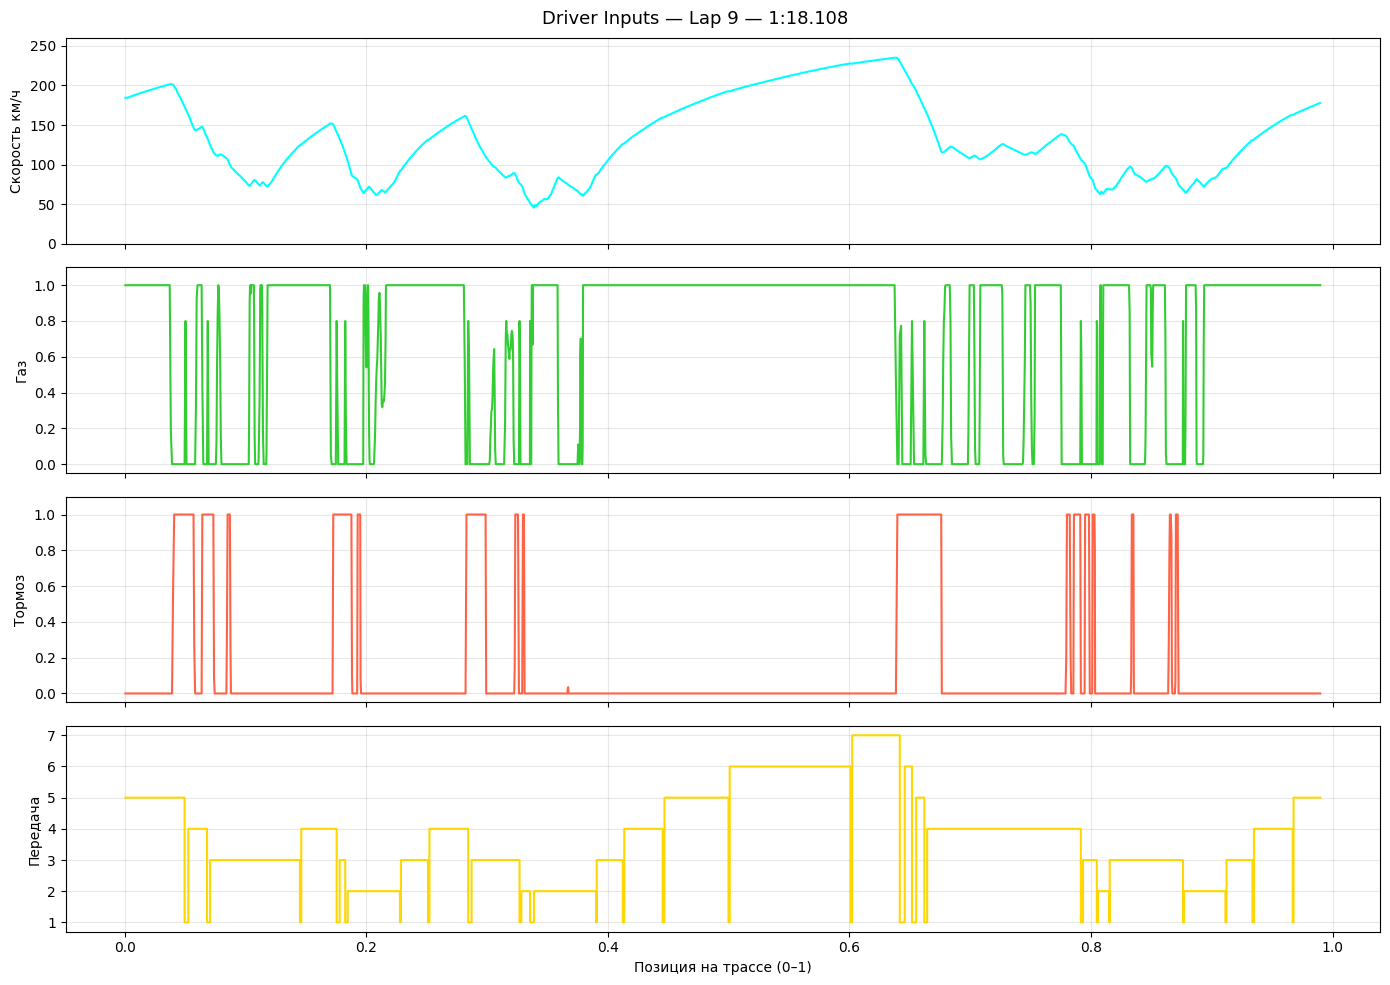

In [49]:
import matplotlib.pyplot as plt

lap_data = clean[clean['lap'] == best_lap].sort_values('normalized_pos')
lap_data = lap_data[lap_data['normalized_pos'] < 0.99]

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(lap_data['normalized_pos'], lap_data['speed_kmh'], color='cyan')
axes[0].set_ylabel('Скорость км/ч')
axes[0].set_ylim(0, 260)

axes[1].plot(lap_data['normalized_pos'], lap_data['throttle'], color='limegreen')
axes[1].set_ylabel('Газ')
axes[1].set_ylim(-0.05, 1.1)

axes[2].plot(lap_data['normalized_pos'], lap_data['brake'], color='tomato')
axes[2].set_ylabel('Тормоз')
axes[2].set_ylim(-0.05, 1.1)

axes[3].plot(lap_data['normalized_pos'], lap_data['gear'], color='gold', drawstyle='steps-post')
axes[3].set_ylabel('Передача')
axes[3].set_xlabel('Позиция на трассе (0–1)')

for ax in axes:
    ax.grid(alpha=0.3)

plt.suptitle(f'Driver Inputs — Lap {best_lap} — {best_lap_time_str}', fontsize=13)
plt.tight_layout()
plt.show()


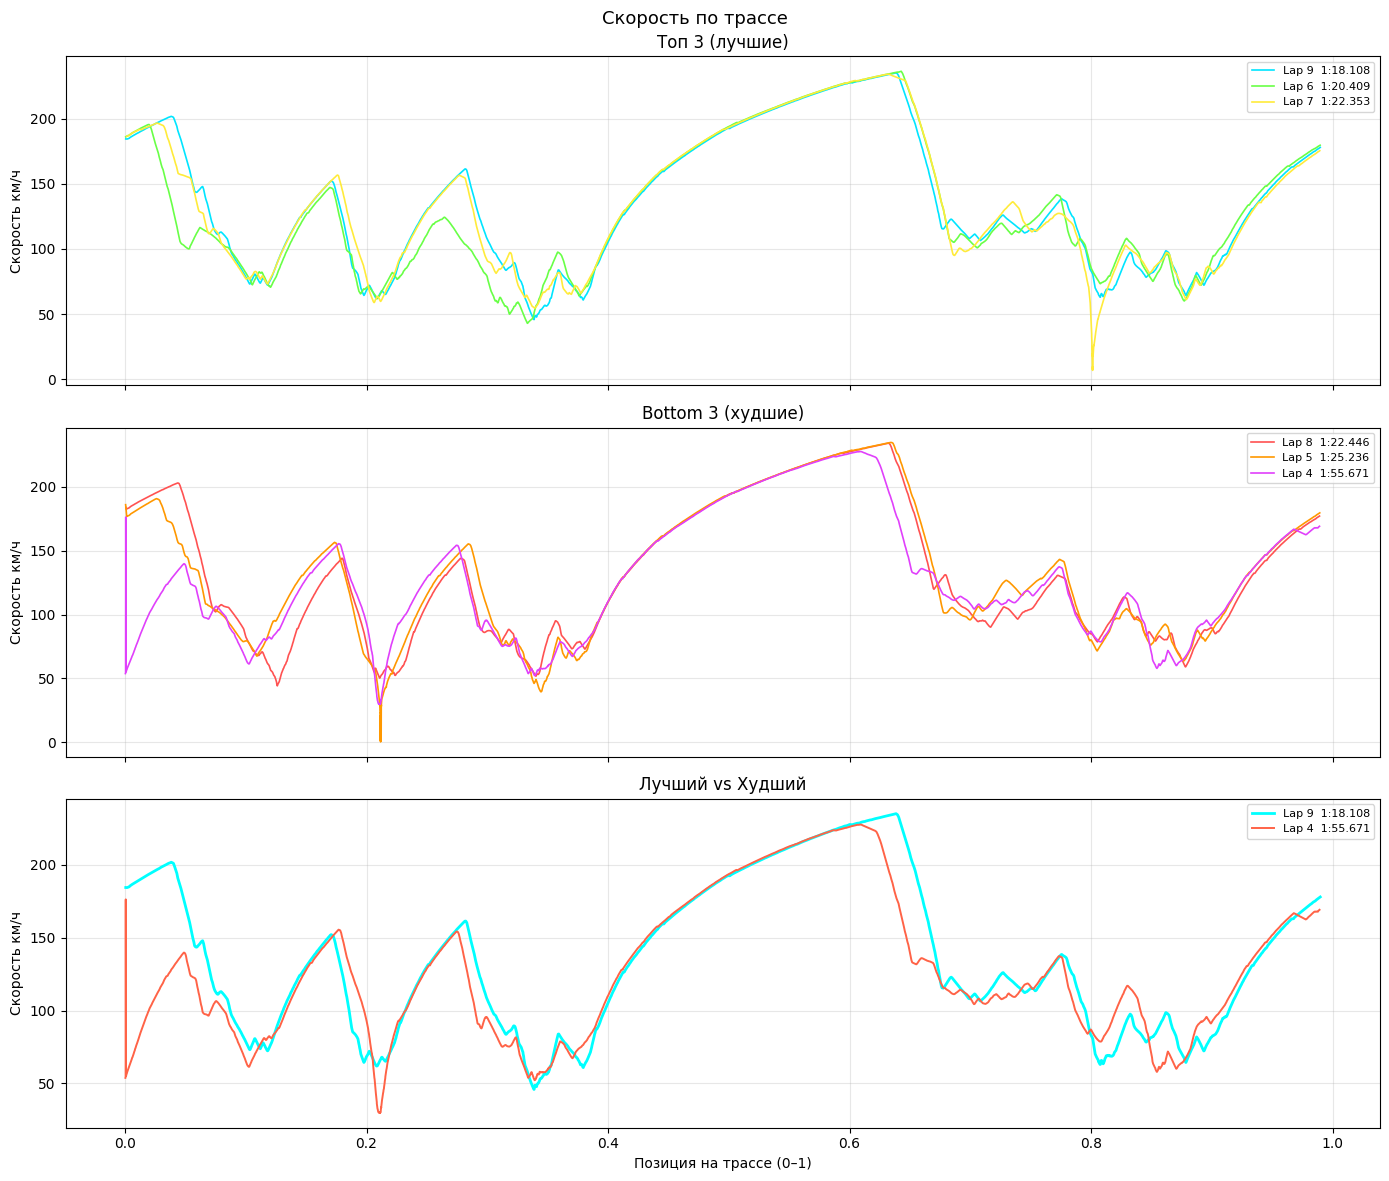

In [50]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

groups = [
    (axes[0], best_laps,  'Топ 3 (лучшие)',   ['#00e5ff', '#69ff47', '#ffeb3b']),
    (axes[1], worst_laps, 'Bottom 3 (худшие)', ['#ff5252', '#ff9800', '#e040fb']),
]
for ax, laps, title, colors in groups:
    for lap_num, color in zip(laps, colors):
        d = clean[clean['lap'] == lap_num].sort_values('normalized_pos')
        d = d[d['normalized_pos'] < 0.99]
        ax.plot(d['normalized_pos'], d['speed_kmh'], color=color, linewidth=1.2, label=lap_label(lap_num))
    ax.set_ylabel('Скорость км/ч')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

for lap_num, color, lw in [(best_lap, 'cyan', 2.0), (worst_lap, 'tomato', 1.4)]:
    d = clean[clean['lap'] == lap_num].sort_values('normalized_pos')
    d = d[d['normalized_pos'] < 0.99]
    axes[2].plot(d['normalized_pos'], d['speed_kmh'], color=color, linewidth=lw, label=lap_label(lap_num))
axes[2].set_ylabel('Скорость км/ч')
axes[2].set_xlabel('Позиция на трассе (0–1)')
axes[2].set_title('Лучший vs Худший')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.suptitle('Скорость по трассе', fontsize=13)
plt.tight_layout()
plt.show()


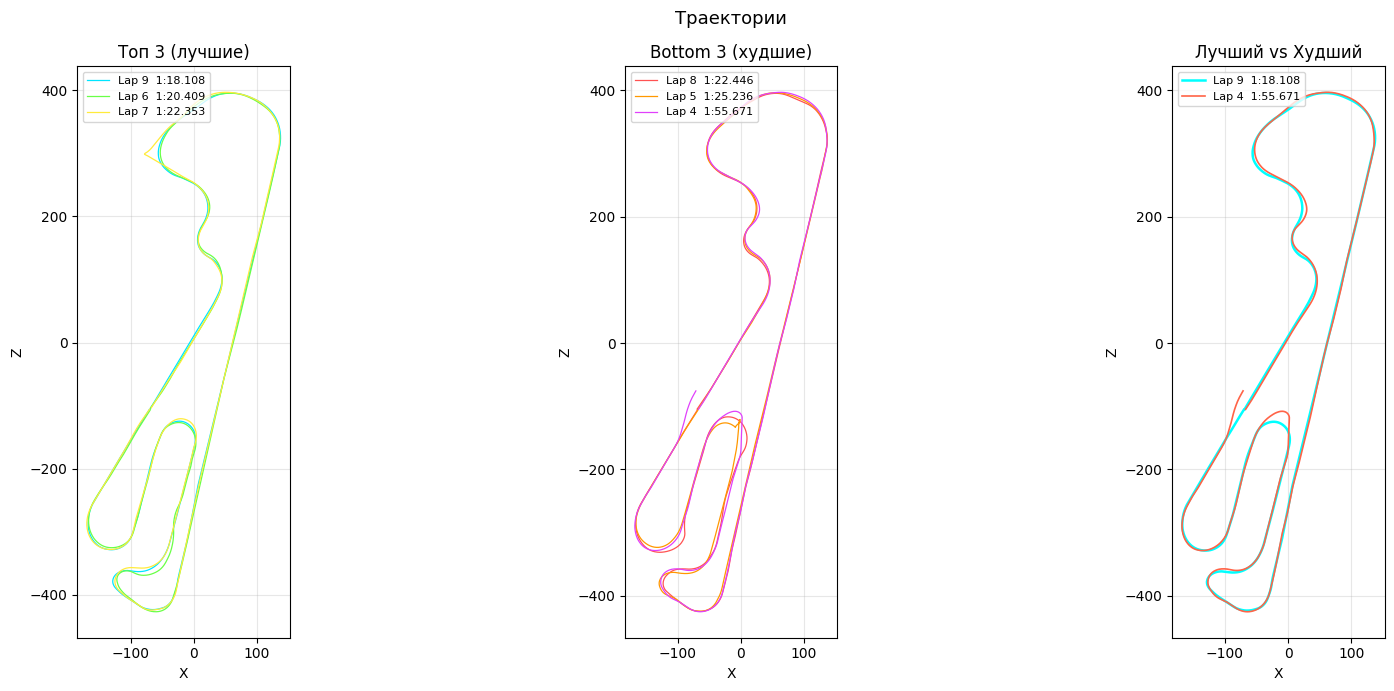

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

groups = [
    (axes[0], best_laps,  'Топ 3 (лучшие)',   ['#00e5ff', '#69ff47', '#ffeb3b']),
    (axes[1], worst_laps, 'Bottom 3 (худшие)', ['#ff5252', '#ff9800', '#e040fb']),
]
for ax, laps, title, colors in groups:
    for lap_num, color in zip(laps, colors):
        d = clean[clean['lap'] == lap_num]
        ax.plot(d['car_x'], d['car_z'], color=color, linewidth=0.9, label=lap_label(lap_num))
    ax.set_xlabel('X'); ax.set_ylabel('Z')
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

for lap_num, color, lw in [(best_lap, 'cyan', 1.8), (worst_lap, 'tomato', 1.2)]:
    d = clean[clean['lap'] == lap_num]
    axes[2].plot(d['car_x'], d['car_z'], color=color, linewidth=lw, label=lap_label(lap_num))
axes[2].set_xlabel('X'); axes[2].set_ylabel('Z')
axes[2].set_aspect('equal')
axes[2].set_title('Лучший vs Худший')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.suptitle('Траектории', fontsize=13)
plt.tight_layout()
plt.show()


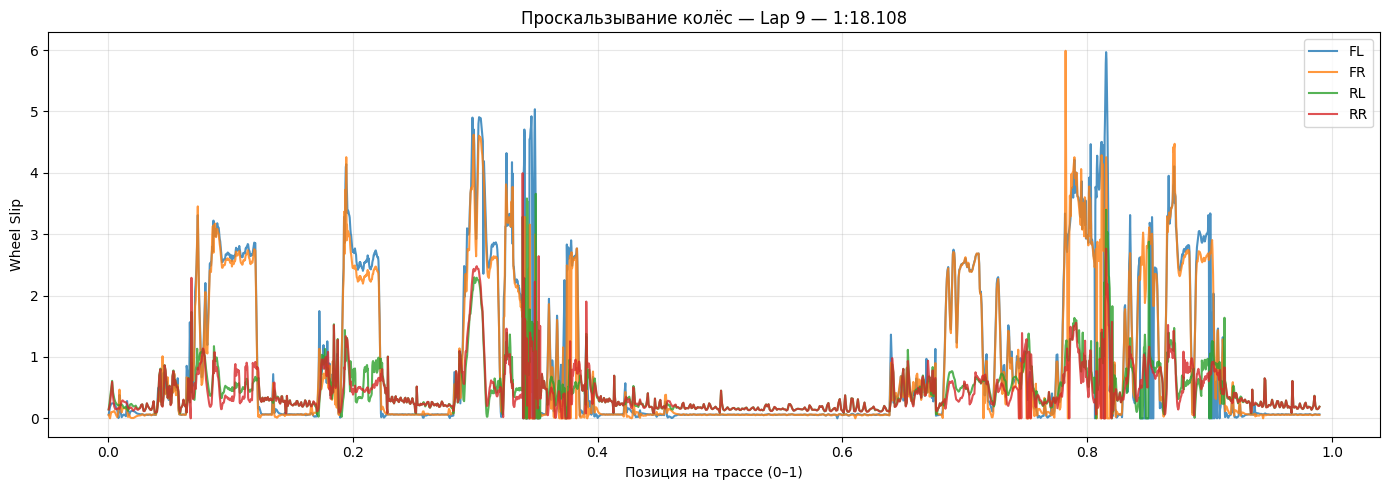

In [52]:
lap_data = clean[clean['lap'] == best_lap].sort_values('normalized_pos')
lap_data = lap_data[lap_data['normalized_pos'] < 0.99]

fig, ax = plt.subplots(figsize=(14, 5))

for col, label in [
    ('wheel_slip_fl', 'FL'),
    ('wheel_slip_fr', 'FR'),
    ('wheel_slip_rl', 'RL'),
    ('wheel_slip_rr', 'RR'),
]:
    ax.plot(lap_data['normalized_pos'], lap_data[col], label=label, alpha=0.8)

ax.set_xlabel('Позиция на трассе (0–1)')
ax.set_ylabel('Wheel Slip')
ax.set_title(f'Проскальзывание колёс — Lap {best_lap} — {best_lap_time_str}')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


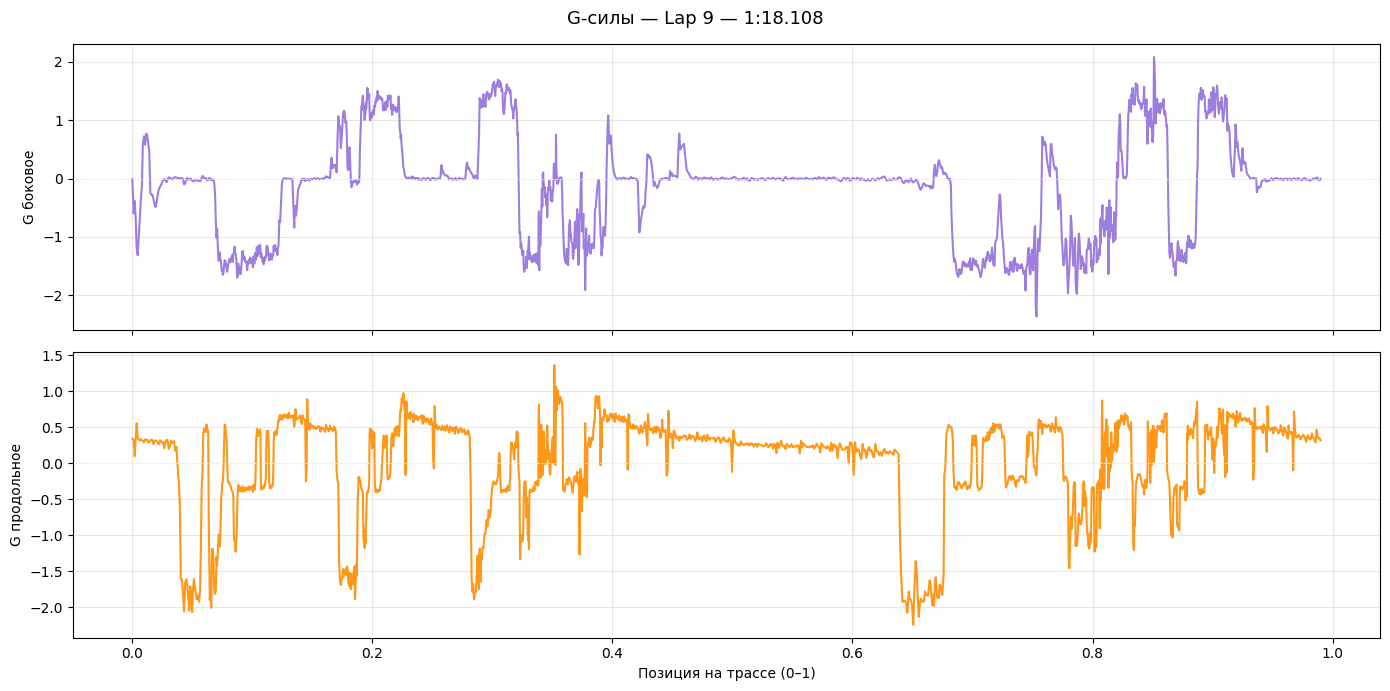

In [53]:
lap_data = clean[clean['lap'] == best_lap].sort_values('normalized_pos')
lap_data = lap_data[lap_data['normalized_pos'] < 0.99]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(lap_data['normalized_pos'], lap_data['g_lat'], color='mediumpurple', alpha=0.9)
axes[0].axhline(0, color='white', linewidth=0.5, linestyle='--')
axes[0].set_ylabel('G боковое')
axes[0].grid(alpha=0.3)

axes[1].plot(lap_data['normalized_pos'], lap_data['g_lon'], color='darkorange', alpha=0.9)
axes[1].axhline(0, color='white', linewidth=0.5, linestyle='--')
axes[1].set_ylabel('G продольное')
axes[1].set_xlabel('Позиция на трассе (0–1)')
axes[1].grid(alpha=0.3)

plt.suptitle(f'G-силы — Lap {best_lap} — {best_lap_time_str}', fontsize=13)
plt.tight_layout()
plt.show()


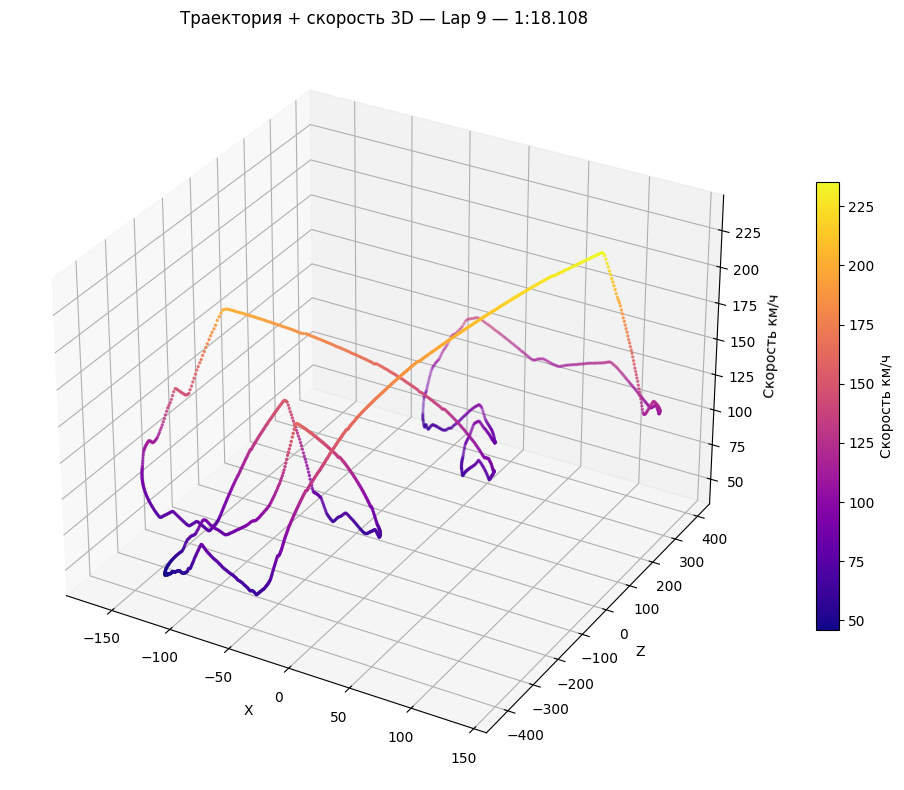

In [54]:
from mpl_toolkits.mplot3d import Axes3D

lap_data = clean[clean['lap'] == best_lap].copy()

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    lap_data['car_x'], lap_data['car_z'], lap_data['speed_kmh'],
    c=lap_data['speed_kmh'], cmap='plasma', s=2
)

plt.colorbar(sc, label='Скорость км/ч', shrink=0.6)
ax.set_xlabel('X')
ax.set_ylabel('Z')
ax.set_zlabel('Скорость км/ч')
ax.set_title(f'Траектория + скорость 3D — Lap {best_lap} — {best_lap_time_str}')
plt.tight_layout()
plt.show()


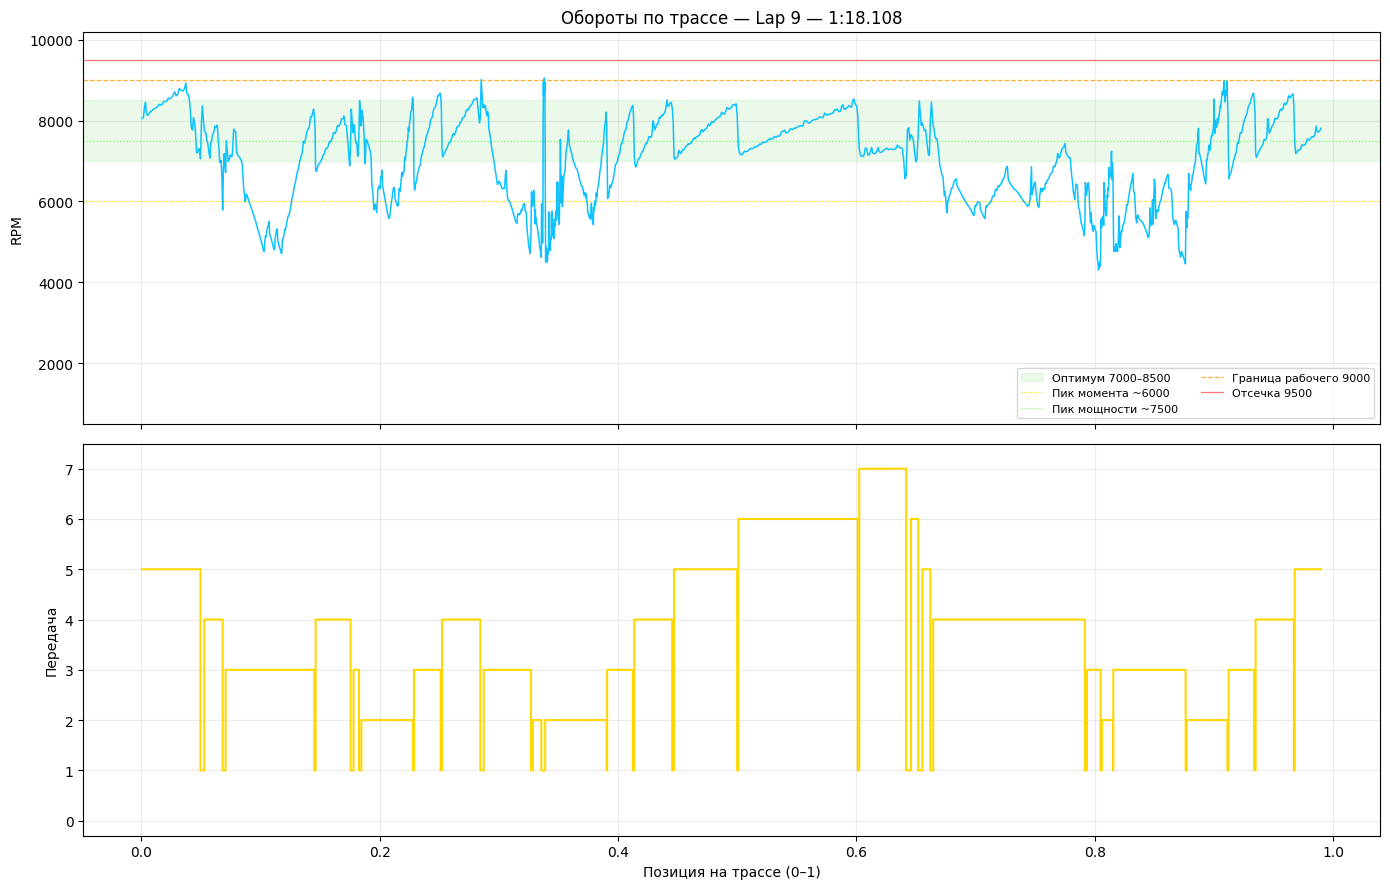

In [55]:
lap_data = clean[clean['lap'] == best_lap].sort_values('normalized_pos')
lap_data = lap_data[lap_data['normalized_pos'] < 0.99]

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

ax = axes[0]
ax.plot(lap_data['normalized_pos'], lap_data['rpms'], color='deepskyblue', linewidth=1.1, alpha=0.95, zorder=3)

# Оптимальная зона 7000-8500
ax.axhspan(7000, 8500, color='limegreen', alpha=0.10, label='Оптимум 7000–8500')

# Ключевые уровни
ref_lines = [
    (6000, '#ffeb3b', '--', 'Пик момента ~6000'),
    (7500, '#69ff47', ':',  'Пик мощности ~7500'),
    (9000, '#ff9800', '--', 'Граница рабочего 9000'),
    (9500, '#ff5252', '-',  'Отсечка 9500'),
]
for rpm, color, ls, label in ref_lines:
    ax.axhline(rpm, color=color, linewidth=0.9, linestyle=ls, alpha=0.8, label=label)

ax.set_ylabel('RPM')
ax.set_ylim(500, 10200)
ax.legend(fontsize=8, loc='lower right', ncol=2)
ax.grid(alpha=0.25)
ax.set_title(f'Обороты по трассе — Lap {best_lap} — {best_lap_time_str}')

axes[1].plot(lap_data['normalized_pos'], lap_data['gear'], color='gold', drawstyle='steps-post')
axes[1].set_ylabel('Передача')
axes[1].set_xlabel('Позиция на трассе (0–1)')
axes[1].set_ylim(-0.3, lap_data['gear'].max() + 0.5)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


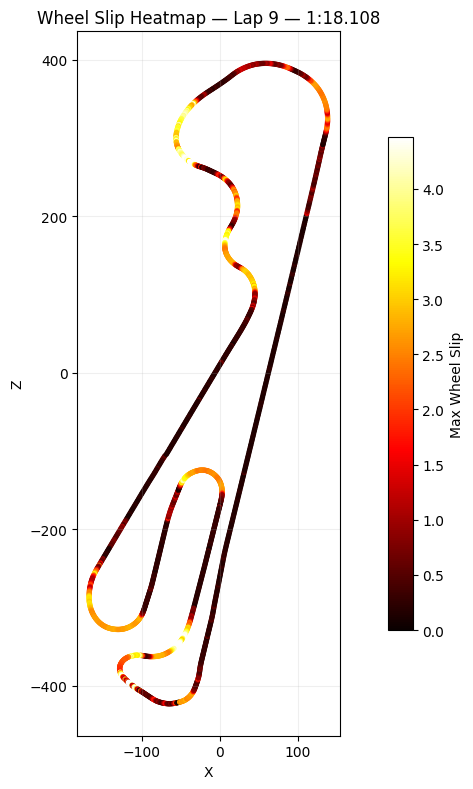

In [56]:
lap_data = clean[clean['lap'] == best_lap].copy()
lap_data['slip_max'] = lap_data[['wheel_slip_fl', 'wheel_slip_fr', 'wheel_slip_rl', 'wheel_slip_rr']].max(axis=1)

fig, ax = plt.subplots(figsize=(10, 8))

sc = ax.scatter(
    lap_data['car_x'], lap_data['car_z'],
    c=lap_data['slip_max'], cmap='hot', s=8, vmin=0, vmax=lap_data['slip_max'].quantile(0.98)
)

plt.colorbar(sc, label='Max Wheel Slip', shrink=0.7)
ax.set_xlabel('X')
ax.set_ylabel('Z')
ax.set_aspect('equal')
ax.set_title(f'Wheel Slip Heatmap — Lap {best_lap} — {best_lap_time_str}')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


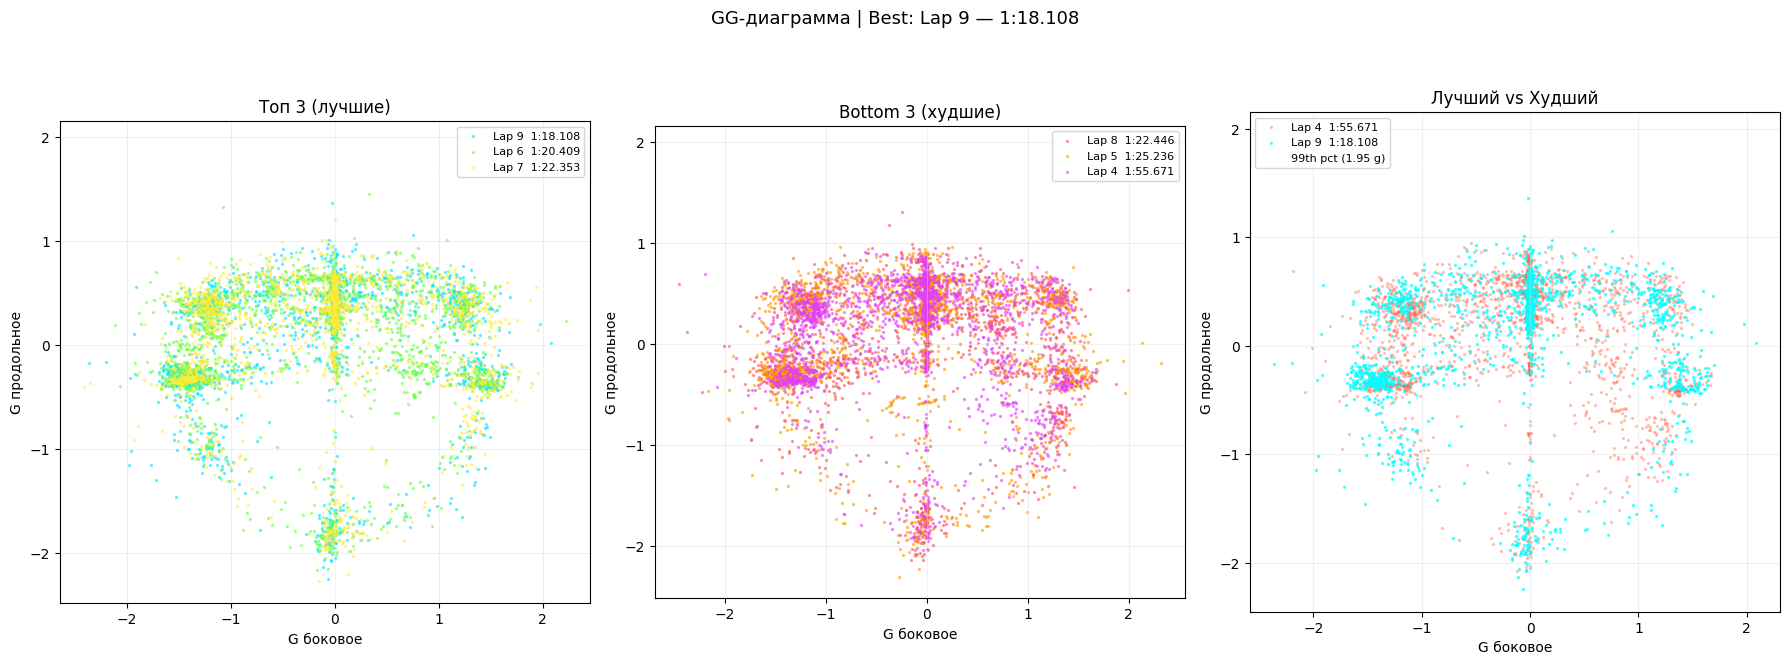

In [57]:
import numpy as np

g_limit = clean[['g_lat', 'g_lon']].apply(
    lambda r: (r['g_lat']**2 + r['g_lon']**2)**0.5, axis=1
).quantile(0.99)
theta = np.linspace(0, 2 * np.pi, 300)

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

groups = [
    (axes[0], best_laps,  'Топ 3 (лучшие)',   ['#00e5ff', '#69ff47', '#ffeb3b']),
    (axes[1], worst_laps, 'Bottom 3 (худшие)', ['#ff5252', '#ff9800', '#e040fb']),
]
for ax, laps, title, colors in groups:
    for lap_num, color in zip(laps, colors):
        d = clean[clean['lap'] == lap_num]
        ax.scatter(d['g_lat'], d['g_lon'], s=2, color=color, alpha=0.5, label=lap_label(lap_num))
    ax.plot(g_limit * np.cos(theta), g_limit * np.sin(theta),
            color='white', linewidth=0.8, linestyle='--', alpha=0.4)
    ax.axhline(0, color='white', linewidth=0.4, alpha=0.4)
    ax.axvline(0, color='white', linewidth=0.4, alpha=0.4)
    ax.set_xlabel('G боковое'); ax.set_ylabel('G продольное')
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

for lap_num, color, alpha in [(worst_lap, 'tomato', 0.3), (best_lap, 'cyan', 0.6)]:
    d = clean[clean['lap'] == lap_num]
    axes[2].scatter(d['g_lat'], d['g_lon'], s=2, color=color, alpha=alpha, label=lap_label(lap_num))
axes[2].plot(g_limit * np.cos(theta), g_limit * np.sin(theta),
             color='white', linewidth=0.8, linestyle='--', alpha=0.4, label=f'99th pct ({g_limit:.2f} g)')
axes[2].axhline(0, color='white', linewidth=0.4, alpha=0.4)
axes[2].axvline(0, color='white', linewidth=0.4, alpha=0.4)
axes[2].set_xlabel('G боковое'); axes[2].set_ylabel('G продольное')
axes[2].set_aspect('equal')
axes[2].set_title('Лучший vs Худший')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.2)

plt.suptitle(f'GG-диаграмма | Best: Lap {best_lap} — {best_lap_time_str}', fontsize=13)
plt.tight_layout()
plt.show()


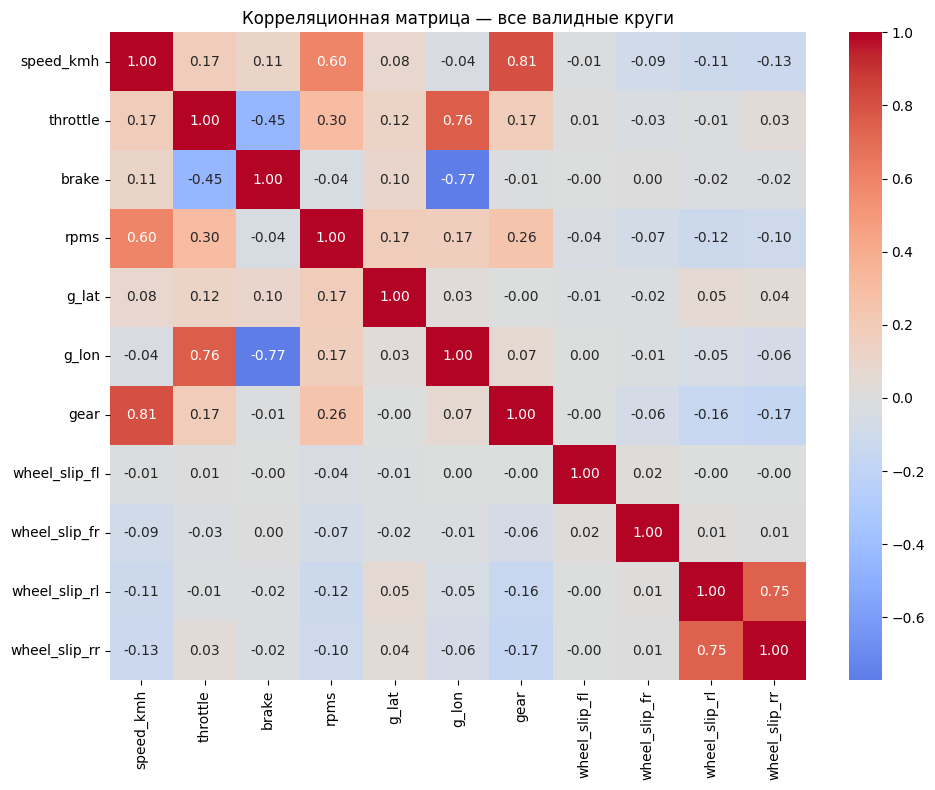

In [58]:
import seaborn as sns

cols = [
    'speed_kmh', 'throttle', 'brake', 'rpms', 'g_lat', 'g_lon', 'gear',
    'wheel_slip_fl', 'wheel_slip_fr', 'wheel_slip_rl', 'wheel_slip_rr',
]
corr = clean[cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Корреляционная матрица — все валидные круги')
plt.tight_layout()
plt.show()
